# Tesla Deliveries - ML Pipeline

**Goal:** Predict Tesla's quarterly deliveries using historical data (2015–2025).

We'll go through the full pipeline step by step:
1. Load & clean the data
2. Explore it (EDA)
3. Engineer useful features
4. Train and compare ML models
5. Tune the best model
6. Forecast future deliveries with SARIMAX

## 1. Imports

Bringing in all the libraries we'll need. XGBoost and statsmodels are optional — the notebook still runs if they're not installed.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
import joblib

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False

# Optional: statsmodels for time series
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    STATS_MODELS_AVAILABLE = True
except:
    STATS_MODELS_AVAILABLE = False

### Config

In [3]:
FILE_PATH    = 'tesla_deliveries_dataset_2015_2025.csv'
OUTPUT_DIR   = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

## 2. Load Data

Let's load the CSV and take a quick look at its shape and the first few rows.

In [4]:
df = pd.read_csv(FILE_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Basic Cleaning

Three quick things:
- Standardize column names (lowercase, underscores instead of spaces)
- Drop duplicate rows
- Strip whitespace from text columns

In [5]:
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

print('Columns after cleaning:', df.columns.tolist())
print('Shape:', df.shape)

Columns after cleaning: ['year', 'month', 'region', 'model', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'source_type', 'charging_stations']
Shape: (2640, 12)


## 4. Auto-detect the Date Column

Since column names can vary across datasets, we scan for date-related keywords and try parsing them. A column is accepted if more than 60% of its values parse as valid dates.

In [6]:
def safe_parse_dates(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return series
    numeric = pd.to_numeric(series, errors='coerce')
    num_ratio = numeric.notna().sum() / max(len(numeric), 1)
    if num_ratio >= 0.8:
        median_val = numeric.dropna().median()
        if 1900 <= median_val <= 2100:
            return pd.to_datetime({'year': numeric.fillna(median_val).astype(int), 'month': 1, 'day': 1})
        elif median_val > 1e12:
            return pd.to_datetime(numeric, unit='ms', errors='coerce')
        elif median_val > 1e9:
            return pd.to_datetime(numeric, unit='s', errors='coerce')
    return pd.to_datetime(series, infer_datetime_format=True, errors='coerce')

date_candidates = [c for c in df.columns if any(k in c for k in ['date', 'month', 'quarter', 'year', 'time'])]
date_col = None

for c in date_candidates:
    try:
        parsed = safe_parse_dates(df[c])
        if parsed.notna().sum() > max(0.6 * len(df), 3):
            yr = parsed.dropna().dt.year
            if yr.min() >= 1990 and yr.max() <= 2100:
                date_col = c
                df[c] = parsed
                break
    except:
        pass

# Fallback: scan all object columns
if date_col is None:
    for c in df.columns:
        if df[c].dtype == 'object':
            parsed = pd.to_datetime(df[c], errors='coerce')
            if parsed.notna().sum() > max(0.6 * len(df), 3):
                date_col = c
                df[c] = parsed
                break

print('Date column found:', date_col)
if date_col:
    print('Range:', df[date_col].min(), '->', df[date_col].max())

Date column found: year
Range: 2015-01-01 00:00:00 -> 2025-01-01 00:00:00


## 5. Auto-detect the Target Column

We look for numeric columns with business-relevant keywords like 'deliveries', 'sales', 'revenue', etc.

In [7]:
target_keywords = ['delivery', 'deliveries', 'sales', 'sold', 'target', 'revenue', 'price', 'volume']
target_candidates = [c for c in df.columns if any(k in c for k in target_keywords)]
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

target_col = None
for c in target_candidates:
    if c in numeric_cols:
        target_col = c
        break

if target_col is None and len(numeric_cols) > 0:
    target_col = numeric_cols[0]

print('Target column:', target_col)

Target column: estimated_deliveries


## 6. Exploratory Data Analysis (EDA)

Before training anything, let's understand the data:
- Are there missing values?
- What do the distributions look like?
- Are features correlated with each other?

Rows: 2640  |  Columns: 12

Missing values:
year                    0
month                   0
region                  0
model                   0
estimated_deliveries    0
production_units        0
avg_price_usd           0
battery_capacity_kwh    0
range_km                0
co2_saved_tons          0
source_type             0
charging_stations       0
dtype: int64


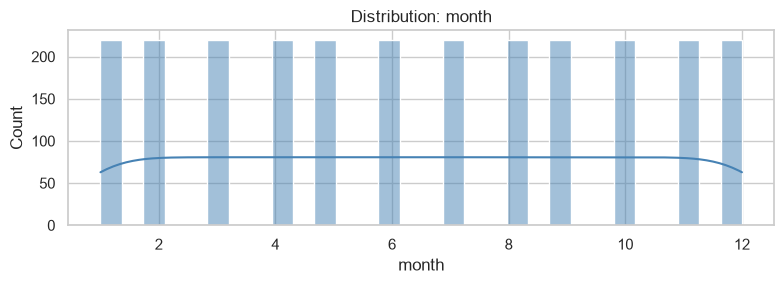

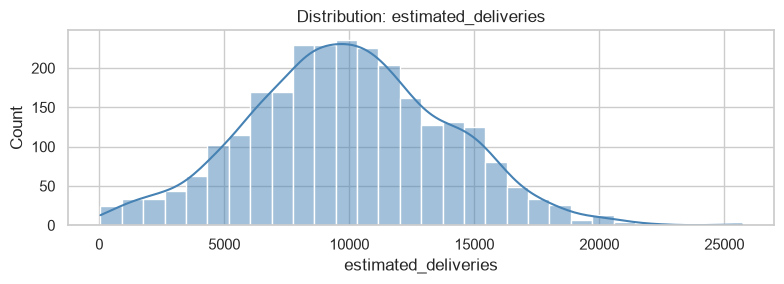

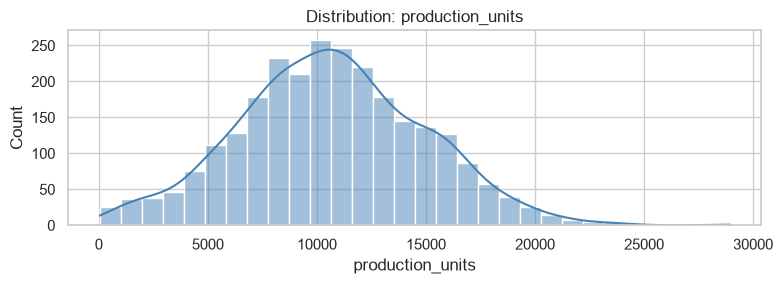

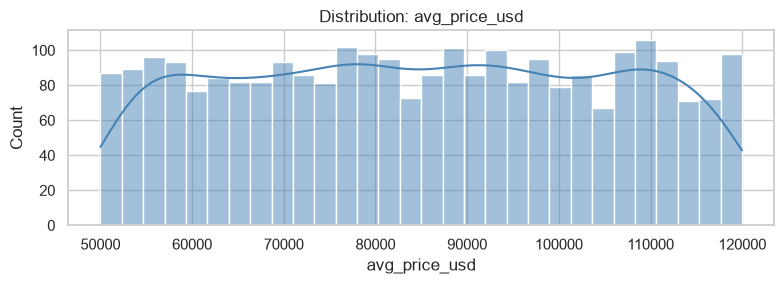

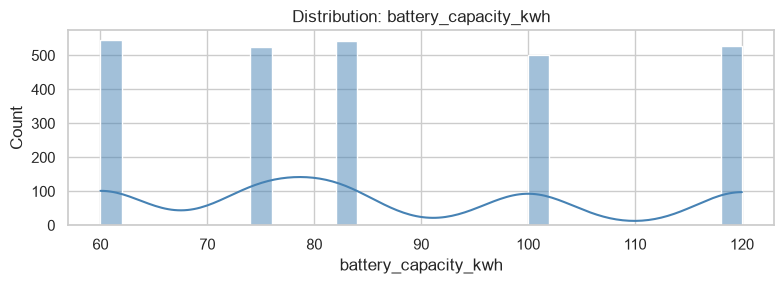

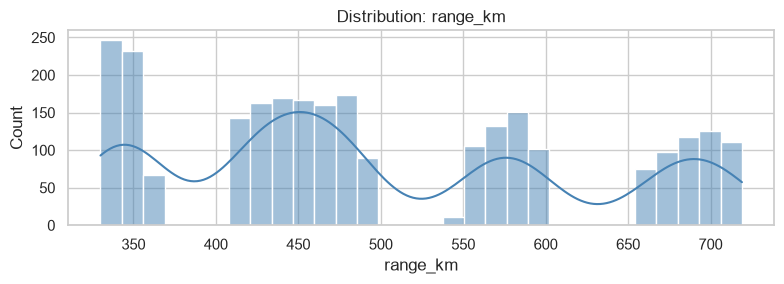

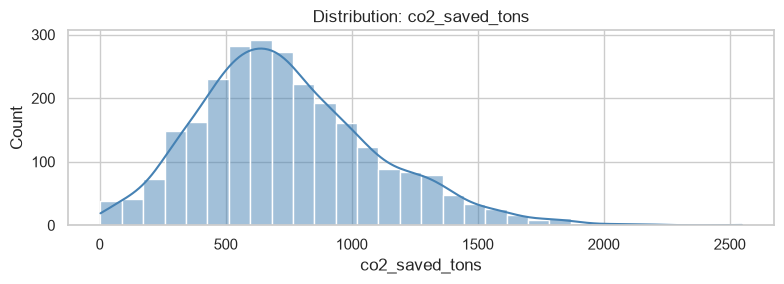

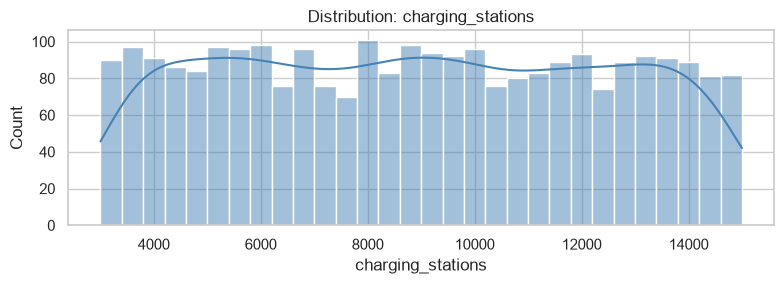

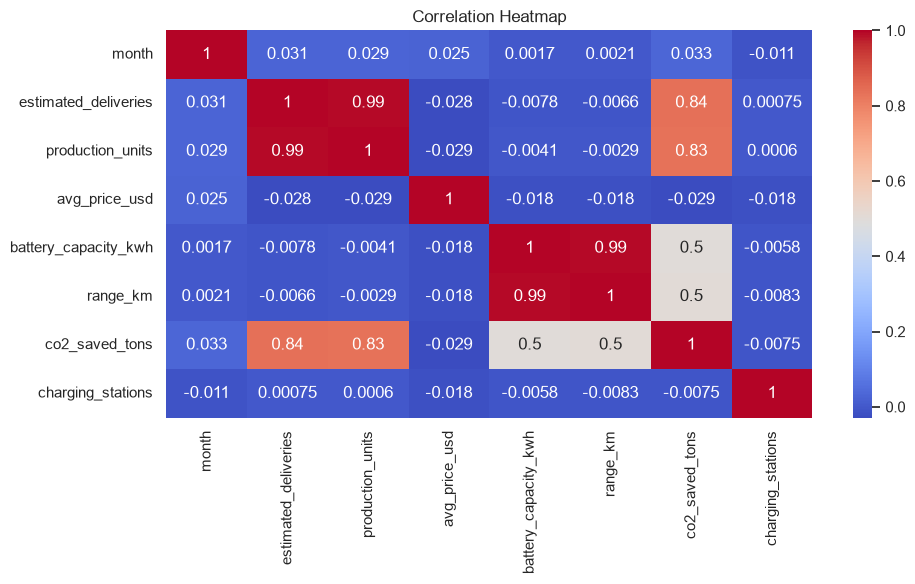

EDA done.


In [8]:
sns.set(style='whitegrid')
df_eda = df.copy()

print(f'Rows: {df_eda.shape[0]}  |  Columns: {df_eda.shape[1]}')
print('\nMissing values:')
print(df_eda.isnull().sum().sort_values(ascending=False))

# Save summary stats
df_eda.describe(include='all').to_csv(os.path.join(OUTPUT_DIR, 'eda_summary.csv'))

num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()

# Missing values bar chart
missing = df_eda.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing.values, y=missing.index, palette='viridis')
    plt.title('Missing Values per Column')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'missing_values.png'), dpi=200)
    plt.show()

# Distribution of each numeric feature
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.histplot(df_eda[col].dropna(), kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution: {col}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{col}_distribution.png'), dpi=200)
    plt.show()

# Correlation heatmap
if len(num_cols) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_eda[num_cols].corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_heatmap.png'), dpi=200)
    plt.show()

print('EDA done.')

## 7. Feature Engineering

We create extra features from the date column and the target itself:

**Calendar features** — year, month, quarter, day of week, month start/end flags

**Lag features** — previous 1–4 periods of the target (so the model sees recent history)

**Rolling stats** — 3 and 6-period moving averages and std dev (captures trend + volatility)

**Interaction terms** — products of top numeric columns (captures non-linear effects)

> Note: lags use `.shift(1)` so we never leak future information into training.

In [9]:
data = df.copy()

# Date features
if date_col and date_col in data.columns:
    dt = pd.to_datetime(data[date_col], errors='coerce')
    if dt.notna().sum() > 0:
        data['year']          = dt.dt.year
        data['month']         = dt.dt.month
        data['day']           = dt.dt.day
        data['dayofweek']     = dt.dt.dayofweek
        data['quarter']       = dt.dt.quarter
        data['is_month_start'] = dt.dt.is_month_start.astype(int)
        data['is_month_end']   = dt.dt.is_month_end.astype(int)
        data[date_col] = dt

# Sort by date
if date_col and date_col in data.columns:
    data = data.sort_values(date_col).reset_index(drop=True)

# Lag and rolling features
if target_col and target_col in data.columns:
    for lag in [1, 2, 3, 4]:
        data[f'{target_col}_lag_{lag}'] = data[target_col].shift(lag)
    for win in [3, 6]:
        data[f'{target_col}_roll_mean_{win}'] = data[target_col].shift(1).rolling(win).mean()
        data[f'{target_col}_roll_std_{win}']  = data[target_col].shift(1).rolling(win).std()

# Interaction terms (top 3 numeric cols)
num_cols_fe = data.select_dtypes(include=np.number).columns.tolist()
for i in range(min(3, len(num_cols_fe))):
    for j in range(i + 1, min(3, len(num_cols_fe))):
        c1, c2 = num_cols_fe[i], num_cols_fe[j]
        data[f'{c1}_x_{c2}'] = data[c1] * data[c2]

print('Feature engineering done. Shape:', data.shape)

Feature engineering done. Shape: (2640, 28)


## 8. Build X and y

Drop rows where the target is missing, then separate features (X) from the label (y). The raw date column is excluded — the calendar features already cover that information.

In [10]:
data = data.dropna(subset=[target_col]).reset_index(drop=True)
data_model = data.dropna().reset_index(drop=True)

y = data_model[target_col].copy()
X = data_model.drop(columns=[target_col])

if date_col and date_col in X.columns:
    X = X.drop(columns=[date_col])

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Total features : {len(X.columns)}')
print(f'Numeric        : {len(num_cols)}')
print(f'Categorical    : {len(cat_cols)}')

Total features : 26
Numeric        : 23
Categorical    : 3


## 9. Train/Test Split

For time series data, we **cannot** split randomly — that would let the model train on future data. Instead we do a chronological split: first 80% for training, last 20% for testing.

In [11]:
if date_col is not None:
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows')

Train: 2107 rows  |  Test: 527 rows


## 10. Preprocessing Pipeline

Using sklearn's `Pipeline` and `ColumnTransformer` so preprocessing is bundled with the model — no chance of fitting scalers on test data by mistake.

- Numeric: fill missing with median → StandardScaler
- Categorical: fill missing with most frequent value → OneHotEncoder

In [12]:
# Refresh column lists after split
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

## 11. Define Models

We'll compare 7–8 different models ranging from simple linear regression to tree ensembles. This gives us a good picture of what works best on this dataset.

In [13]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge'            : Ridge(random_state=RANDOM_STATE),
    'Lasso'            : Lasso(random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet'       : ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    'RandomForest'     : RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    'GradientBoosting' : GradientBoostingRegressor(random_state=RANDOM_STATE),
    'ExtraTrees'       : ExtraTreesRegressor(n_estimators=400, random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE
    )

print(f'{len(models)} models ready to train')

8 models ready to train


## 12. Train and Evaluate

Each model is wrapped in a pipeline (preprocessor + estimator), fit on training data, and scored on the test set. We track four metrics:

- **RMSE** — root mean squared error (same unit as target)
- **MAE** — mean absolute error (less sensitive to big outliers)
- **R²** — how much variance the model explains (1.0 = perfect)
- **MAPE** — mean absolute percentage error (easy to interpret in business terms)

In [14]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return rmse, mae, r2, mape

results       = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse, mae, r2, mape = regression_metrics(y_test, preds)
    results.append([name, rmse, mae, r2, mape])
    fitted_models[name] = pipe
    print(f'{name:<20}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}  MAPE={mape:.1f}%')

results_df = pd.DataFrame(results, columns=['model', 'rmse', 'mae', 'r2', 'mape'])
results_df = results_df.sort_values('rmse').reset_index(drop=True)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'), index=False)

print('\nBest model:', results_df.iloc[0]['model'])
results_df

LinearRegression      RMSE=0.00  MAE=0.00  R²=1.0000  MAPE=0.0%
Ridge                 RMSE=18.42  MAE=15.11  R²=1.0000  MAPE=0.2%
Lasso                 RMSE=0.93  MAE=0.75  R²=1.0000  MAPE=0.0%
ElasticNet            RMSE=494.29  MAE=375.99  R²=0.9824  MAPE=7.1%
RandomForest          RMSE=14.64  MAE=7.86  R²=1.0000  MAPE=0.2%
GradientBoosting      RMSE=44.39  MAE=32.87  R²=0.9999  MAPE=0.4%
ExtraTrees            RMSE=13.91  MAE=7.85  R²=1.0000  MAPE=0.1%
XGBoost               RMSE=42.40  MAE=30.85  R²=0.9999  MAPE=0.5%

Best model: LinearRegression


,model,rmse,mae,r2,mape
0,LinearRegression,3.553071e-12,2.742290e-12,1.000000,3.029027e-14
1,Lasso,9.335761e-01,7.504765e-01,1.000000,1.254582e-02
2,ExtraTrees,1.390737e+01,7.845550e+00,0.999986,1.342303e-01
3,RandomForest,1.464208e+01,7.862878e+00,0.999985,1.718652e-01
4,Ridge,1.842254e+01,1.511273e+01,0.999976,1.919307e-01
5,XGBoost,4.239813e+01,3.085093e+01,0.999870,4.654131e-01
6,GradientBoosting,4.439196e+01,3.287483e+01,0.999858,4.284943e-01
7,ElasticNet,4.942945e+02,3.759883e+02,0.982374,7.140715e+00


## 13. Feature Importance

We use **permutation importance** on the best model — it works for any model type (not just trees). Each feature is shuffled one at a time, and we measure how much the score drops. A bigger drop = more important feature.

In [ ]:
best_model_name = results_df.iloc[0]['model']
best_model      = fitted_models[best_model_name]

try:
    perm = permutation_importance(
        best_model, X_test, y_test,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    importance_df = pd.DataFrame({
        'feature'         : X_test.columns,
        'importance_mean' : perm.importances_mean,
        'importance_std'  : perm.importances_std
    }).sort_values('importance_mean', ascending=False)

    importance_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_importance.csv'), index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x='importance_mean', y='feature', palette='magma')
    plt.title(f'Top 15 Features — {best_model_name}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=200)
    plt.show()
    print(importance_df.head(10).to_string(index=False))
except Exception as e:
    print('Could not compute feature importance:', e)

## 14. Residual Analysis

Let's check the errors our best model makes. A well-behaved model should have residuals that:
- Are centered around zero (no systematic bias)
- Don't fan out as predictions get larger (no heteroscedasticity)
- Look roughly bell-shaped

In [ ]:
best_preds = best_model.predict(X_test)
residuals  = y_test - best_preds

# Save residuals
pd.DataFrame({'actual': y_test.values, 'predicted': best_preds, 'residual': residuals})\
    .to_csv(os.path.join(OUTPUT_DIR, 'residuals.csv'), index=False)

# Residuals vs predicted
plt.figure(figsize=(8, 4))
sns.scatterplot(x=best_preds, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residual_plot.png'), dpi=200)
plt.show()

# Residual distribution
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residual_distribution.png'), dpi=200)
plt.show()

## 15. Save Model and Predictions

Save the best pipeline to disk with `joblib` (ready for deployment), and export the test predictions as a CSV.

In [ ]:
# Save model
model_path = os.path.join(OUTPUT_DIR, f'best_model_{best_model_name}.pkl')
joblib.dump(best_model, model_path)
print('Model saved to:', model_path)

# Save predictions
pd.DataFrame({'actual': y_test.values, 'predicted': best_preds})\
    .to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)
print('Predictions saved.')

## 16. Time Series Forecasting with SARIMAX

Instead of treating this as a pure regression problem, we can also model the delivery numbers directly as a time series. SARIMAX handles trend, autocorrelation, and seasonality.

We do a grid search over ARIMA orders, pick the one with the lowest AIC, evaluate on held-out years, and then refit on all data to forecast 5 years into the future.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

print('date_col:', date_col)
print('target_col:', target_col)
print('Sample dates:', df[date_col].dropna().unique()[:10].tolist())

In [ ]:
forecast_results = None

if not STATS_MODELS_AVAILABLE:
    print('statsmodels not installed — skipping SARIMAX.')
else:
    # Build a yearly aggregated series
    temp = pd.DataFrame({
        'year'  : pd.to_datetime(df[date_col], errors='coerce').dt.year,
        'target': pd.to_numeric(df[target_col], errors='coerce')
    }).dropna()
    temp = temp[temp['year'].between(1990, 2100)]
    yearly = temp.groupby('year')['target'].sum().sort_index()
    yearly.index = pd.to_datetime(yearly.index.astype(int).astype(str), format='%Y')
    ts_series = yearly.dropna()

    print('Years:', [i.year for i in ts_series.index])
    print('Observations:', len(ts_series))

    # Plot historical series
    plt.figure(figsize=(12, 4))
    plt.plot(ts_series.index, ts_series.values, marker='o', color='royalblue')
    plt.title(f'Yearly Deliveries — {target_col}')
    plt.xlabel('Year'); plt.ylabel(target_col)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'time_series_original.png'), dpi=200)
    plt.show()

    if len(ts_series) < 6:
        print('Not enough data points for SARIMAX (need at least 6).')
    else:
        # Train/test split
        split_idx = max(int(len(ts_series) * 0.80), len(ts_series) - 3)
        train_ts  = ts_series.iloc[:split_idx]
        test_ts   = ts_series.iloc[split_idx:]

        print(f'Train: {len(train_ts)} pts  |  Test: {len(test_ts)} pts')

        # Naive baseline
        naive_pred = np.repeat(train_ts.iloc[-1], len(test_ts))
        print(f'Naive RMSE: {np.sqrt(mean_squared_error(test_ts, naive_pred)):.2f}')

        # Grid search over ARIMA orders
        orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,0)]
        best_aic, best_fit, best_order = np.inf, None, None

        for order in orders:
            try:
                fit = SARIMAX(
                    train_ts, order=order, seasonal_order=(0,0,0,0),
                    enforce_stationarity=False, enforce_invertibility=False
                ).fit(disp=False)
                if np.isfinite(fit.aic) and fit.aic < best_aic:
                    best_aic, best_fit, best_order = fit.aic, fit, order
            except:
                continue

        if best_fit is None:
            print('No valid SARIMAX model found.')
        else:
            fc       = best_fit.get_forecast(steps=len(test_ts))
            pred     = fc.predicted_mean
            conf_int = fc.conf_int()

            ts_rmse = np.sqrt(mean_squared_error(test_ts, pred))
            ts_mae  = mean_absolute_error(test_ts, pred)
            ts_r2   = r2_score(test_ts, pred)
            print(f'Best order: {best_order}  AIC: {best_aic:.2f}')
            print(f'Test RMSE={ts_rmse:.2f}  MAE={ts_mae:.2f}  R²={ts_r2:.4f}')

            # Test forecast plot
            plt.figure(figsize=(12, 5))
            plt.plot(train_ts.index, train_ts.values, label='Train',    color='steelblue', marker='o')
            plt.plot(test_ts.index,  test_ts.values,  label='Actual',   color='black',     marker='o')
            plt.plot(pred.index,     pred.values,     label='Forecast', color='tomato',    marker='o')
            plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, color='tomato')
            plt.title('SARIMAX — Test Forecast vs Actual')
            plt.xlabel('Year'); plt.ylabel(target_col); plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, 'sarimax_forecast.png'), dpi=200)
            plt.show()

            # Refit on all data and forecast 5 years ahead
            final_fit   = SARIMAX(ts_series, order=best_order, seasonal_order=(0,0,0,0),
                                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            future_fc   = final_fit.get_forecast(steps=5)
            future_pred = future_fc.predicted_mean
            future_ci   = future_fc.conf_int()

            last_year    = ts_series.index.max().year
            future_years = list(range(last_year + 1, last_year + 6))
            future_idx   = pd.to_datetime([str(y) for y in future_years], format='%Y')

            forecast_results = pd.DataFrame({'Year': future_years, 'Forecast': future_pred.values})
            forecast_results.to_csv(os.path.join(OUTPUT_DIR, 'future_forecast.csv'), index=False)

            print('\n5-Year Forecast:')
            print(forecast_results.to_string(index=False))

            plt.figure(figsize=(12, 5))
            plt.plot(ts_series.index, ts_series.values, label='Historical',     color='royalblue',  marker='o')
            plt.plot(future_idx,      future_pred.values, label='Future Forecast', color='darkorange', marker='o')
            plt.fill_between(future_idx, future_ci.iloc[:,0].values, future_ci.iloc[:,1].values,
                             alpha=0.2, color='darkorange')
            plt.title(f'5-Year Forecast Beyond {last_year}')
            plt.xlabel('Year'); plt.ylabel(target_col); plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, 'future_forecast.png'), dpi=200)
            plt.show()

## 17. Summary

Quick recap of what was produced.

In [ ]:
print('=' * 50)
print('PIPELINE COMPLETE')
print('=' * 50)
print('Best ML model    :', best_model_name)
print('Output directory :', OUTPUT_DIR)
print('Files saved:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print('  -', f)

if forecast_results is not None:
    print('\n5-Year Delivery Forecast:')
    print(forecast_results.to_string(index=False))